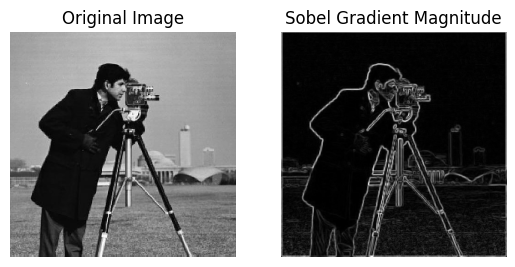

In [1]:
#Task-1A
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
from skimage import io

def zero_pad(image, pad_size):
    padded_image = np.zeros((image.shape[0] + 2 * pad_size, image.shape[1] + 2 * pad_size))
    padded_image[pad_size:-pad_size, pad_size:-pad_size] = image
    return padded_image

def sobel_operator():
    image_size = 300
    image_path = './Images/cameraman.jpeg'
    original_image = io.imread(image_path)
    original_image = scipy.ndimage.zoom(original_image, (image_size / original_image.shape[0], image_size / original_image.shape[1]))

    sobel_horizontal_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_vertical_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    pad_size = 1
    padded_original_image = zero_pad(original_image, pad_size)

    horizontal_edge_image = scipy.ndimage.convolve(padded_original_image, sobel_horizontal_kernel)
    vertical_edge_image = scipy.ndimage.convolve(padded_original_image, sobel_vertical_kernel)
    gradient_magnitude = np.sqrt(horizontal_edge_image**2 + vertical_edge_image**2)

    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap=plt.cm.gray)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gradient_magnitude, cmap=plt.cm.gray)
    plt.title('Sobel Gradient Magnitude')
    plt.axis('off')
    plt.show()

sobel_operator()


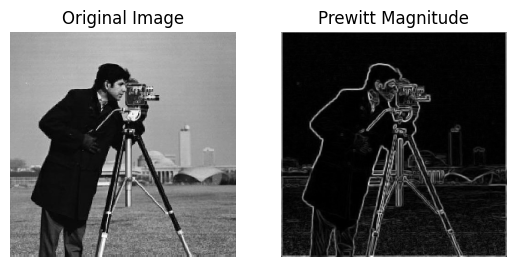

In [2]:
#Task-1B
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
from skimage import io

def zero_pad(image, pad_size):
    padded_image = np.zeros((image.shape[0] + 2 * pad_size, image.shape[1] + 2 * pad_size))
    padded_image[pad_size:-pad_size, pad_size:-pad_size] = image
    return padded_image

def prewitt_operator():
    image_size = 300
    image_path = './Images/cameraman.jpeg'
    original_image = io.imread(image_path)
    original_image = scipy.ndimage.zoom(original_image, (image_size / original_image.shape[0], image_size / original_image.shape[1]))

    prewitt_horizontal_kernel = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    prewitt_vertical_kernel = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

    pad_size = 1
    padded_original_image = zero_pad(original_image, pad_size)

    horizontal_edge_image = scipy.ndimage.convolve(padded_original_image, prewitt_horizontal_kernel)
    vertical_edge_image = scipy.ndimage.convolve(padded_original_image, prewitt_vertical_kernel)
    gradient_magnitude = np.sqrt(horizontal_edge_image**2 + vertical_edge_image**2)

    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap=plt.cm.gray)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gradient_magnitude, cmap=plt.cm.gray)
    plt.title('Prewitt Magnitude')
    plt.axis('off')

    plt.show()

prewitt_operator()


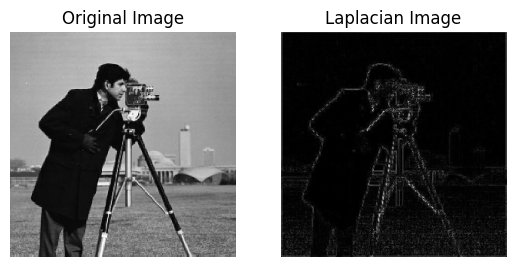

In [3]:
#Task-1C
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
from skimage import io,data

def zero_pad(image, pad_size):
    padded_image = np.zeros((image.shape[0] + 2 * pad_size, image.shape[1] + 2 * pad_size))
    padded_image[pad_size:-pad_size, pad_size:-pad_size] = image
    return padded_image

def laplace_operator():
    image_size = 300
    image_path = './Images/cameraman.jpeg'
    original_image = io.imread(image_path)
    original_image = scipy.ndimage.zoom(original_image, (image_size / original_image.shape[0], image_size / original_image.shape[1]))

    laplacian_kernel = np.array([[0, 1., 0], [1, -4, 1], [0, 1, 0]])
    padded_image = zero_pad(original_image, pad_size=1)  
    processed_image = scipy.ndimage.convolve(padded_image, laplacian_kernel)

    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap=plt.cm.gray)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(np.abs(processed_image), cmap=plt.cm.gray)
    plt.title('Laplacian Image')
    plt.axis('off')
    plt.show()

laplace_operator()


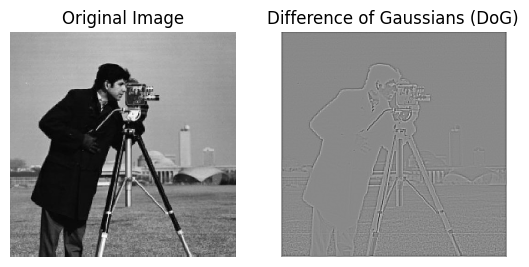

In [120]:
#Task-1D
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
from skimage import io,data

def zero_pad(image, pad_size):
    padded_image = np.zeros((image.shape[0] + 2 * pad_size, image.shape[1] + 2 * pad_size))
    padded_image[pad_size:-pad_size, pad_size:-pad_size] = image
    return padded_image

def difference_of_gaussians(image_size=300, sigma1=1, sigma2=.4):
    image_path = './Images/cameraman.jpeg'
    original_image = io.imread(image_path)
    original_image = scipy.ndimage.zoom(original_image, (image_size / original_image.shape[0], image_size / original_image.shape[1]))
    padded_image = zero_pad(original_image, pad_size=1)

    gaussian1 = scipy.ndimage.gaussian_filter(padded_image, sigma=sigma1)
    gaussian2 = scipy.ndimage.gaussian_filter(padded_image, sigma=sigma2)
    dog_image = gaussian1 - gaussian2

    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap=plt.cm.gray)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(dog_image, cmap=plt.cm.gray)
    plt.title('Difference of Gaussians (DoG)')
    plt.axis('off')
    plt.show()

difference_of_gaussians()


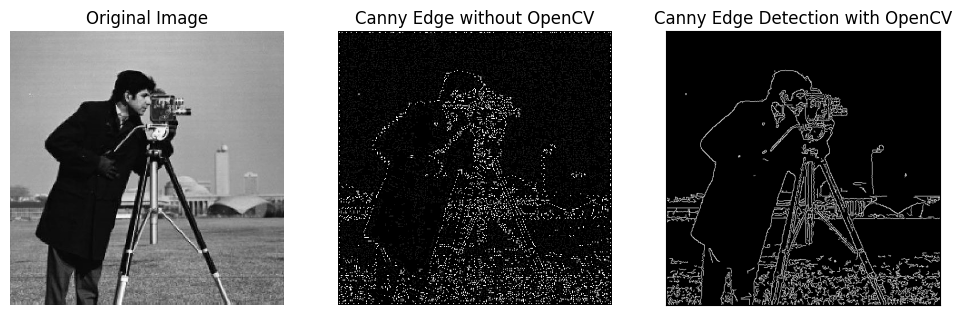

In [96]:
#Task-2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
import scipy.ndimage
from skimage import io,data
import cv2 as cv

def zero_pad(image, pad_size):
    padded_image = np.zeros((image.shape[0] + 2 * pad_size, image.shape[1] + 2 * pad_size))
    padded_image[pad_size:-pad_size, pad_size:-pad_size] = image
    return padded_image
    
def sobel_filter(image):
    sobel_horizontal_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_vertical_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    pad_size = 1
    padded_original_image = zero_pad(image, pad_size)

    horizontal_edge_image = scipy.ndimage.convolve(padded_original_image, sobel_horizontal_kernel)
    vertical_edge_image = scipy.ndimage.convolve(padded_original_image, sobel_vertical_kernel)
    gradient_magnitude = np.sqrt(horizontal_edge_image**2 + vertical_edge_image**2)
    
    gradient_direction = np.arctan2(horizontal_edge_image, vertical_edge_image)
    return gradient_magnitude, gradient_direction

def non_maximum_suppression(magnitude, direction, pad_size):
    rows, cols = magnitude.shape
    result = np.zeros((rows, cols), dtype=np.int32)

    angles_degrees = direction * 180. / np.pi
    angles_degrees[angles_degrees < 0] += 180

    for i in range(pad_size, rows - pad_size):
        for j in range(pad_size, cols - pad_size):
            left, right, up_left, up_right, down_left, down_right = magnitude[i, j-1], magnitude[i, j+1], magnitude[i-1, j-1], magnitude[i-1, j+1], magnitude[i+1, j-1], magnitude[i+1, j+1]
            current_magnitude = magnitude[i, j]
            q, r = 255, 255

            if (0 <= angles_degrees[i, j] < 22.5) or (157.5 <= angles_degrees[i, j] <= 180):
                q, r = left, right
            elif 22.5 <= angles_degrees[i, j] < 67.5:
                q, r = up_right, down_left
            elif 67.5 <= angles_degrees[i, j] < 112.5:
                q, r = magnitude[i-1, j], magnitude[i+1, j]
            elif 112.5 <= angles_degrees[i, j] < 157.5:
                q, r = up_left, down_right

            result[i, j] = current_magnitude if current_magnitude >= max(q, r) else 0

    return result


def double_threshold(image, low_threshold_ratio=0.05, high_threshold_ratio=0.2):
    high_threshold = np.max(image) * high_threshold_ratio
    low_threshold = high_threshold * low_threshold_ratio

    strong_edges = (image >= high_threshold)
    weak_edges = (image >= low_threshold) & (image < high_threshold)

    combined_edges = np.zeros_like(image, dtype=np.uint8)
    combined_edges[strong_edges] = 255
    combined_edges[weak_edges] = 25  # Assigning a different intensity to weak edges

    return combined_edges

def hysteresis(img, low_threshold, high_threshold):
    M, N = img.shape
    weak = low_threshold
    strong = high_threshold

    for i in range(1, M-1):
        for j in range(1, N-1):
            if (img[i, j] == weak):
                if (
                    (img[i+1, j-1] == strong) or (img[i+1, j] == strong) or
                    (img[i+1, j+1] == strong) or (img[i, j-1] == strong) or
                    (img[i, j+1] == strong) or (img[i-1, j-1] == strong) or
                    (img[i-1, j] == strong) or (img[i-1, j+1] == strong)
                ):
                    img[i, j] = strong
                else:
                    img[i, j] = 0
    return img


def canny_edge_detection(image, sigma1, low_threshold_ratio=0.05, high_threshold_ratio=0.09):
    
    smoothed_image = scipy.ndimage.gaussian_filter(image, sigma=sigma1)
    gradient_magnitude, gradient_direction = sobel_filter(smoothed_image)
    pad_size = 1  # Adjust this based on your zero-padding size
    suppressed_image = non_maximum_suppression(gradient_magnitude, gradient_direction, pad_size)

    # Step 4: Apply double thresholding with hysteresis
    low_threshold = np.max(suppressed_image) * low_threshold_ratio
    high_threshold = np.max(suppressed_image) * high_threshold_ratio

    combined = double_threshold(suppressed_image, low_threshold_ratio, high_threshold_ratio)
    result = hysteresis(combined, low_threshold, high_threshold)

    return result



image_size = 300
image_path = './Images/cameraman.jpeg'
original_image = io.imread(image_path)
original_image = scipy.ndimage.zoom(original_image, (image_size / original_image.shape[0], image_size / original_image.shape[1]))

canny_edges = canny_edge_detection(original_image, sigma1=.5)

plt.figure(figsize=(12, 6))
plt.subplot(1,3,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edge without OpenCV')
plt.axis('off')

import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
img = cv.imread('./Images/cameraman.jpeg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
edges = cv.Canny(img,100,200)
plt.subplot(1,3,3),plt.imshow(edges,cmap = 'gray')
plt.title('Canny Edge Detection with OpenCV'), plt.xticks([]), plt.yticks([])
plt.show()


In [ ]:
#Task-3
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, feature
import cv2

def hough_transform(img_edges, theta_res=1, rho_res=.5):
    height, width = img_edges.shape
    diag_len = int(np.sqrt(height**2 + width**2))
    
    thetas = np.deg2rad(np.arange(-10, 90, theta_res))
    rhos = np.arange(-diag_len, diag_len, rho_res)
    
    hough_space = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
    
    edge_indices = np.argwhere(img_edges != 0)
    
    for edge_pixel in edge_indices:
        y, x = edge_pixel
        
        for theta_index, theta in enumerate(thetas):
            rho = int(x * np.cos(theta) + y * np.sin(theta))
            rho_index = np.argmin(np.abs(rhos - rho))
            
            hough_space[rho_index, theta_index] += 1
            
    return hough_space, thetas, rhos

def hough_peaks(hough_space, num_peaks):
    indices = np.argpartition(hough_space.flatten(), -num_peaks)[-num_peaks:]
    peaks = np.column_stack(np.unravel_index(indices, hough_space.shape))
    return peaks

def draw_lines(image, peaks, thetas, rhos, min_line_length):
    result_img = np.copy(image)
    for peak in peaks:
        rho, theta = rhos[peak[0]], thetas[peak[1]]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        
        line_length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        
        if line_length >= min_line_length:
            cv2.line(result_img, (x1, y1), (x2, y2), (0, 255, 0), 1)
    
    return result_img


image_path = './Images/lines.jpg'
org_img = io.imread(image_path)
gray = color.rgb2gray(org_img)

edges = feature.canny(gray, sigma=1)

hough_space, thetas, rhos = hough_transform(edges)

peaks = hough_peaks(hough_space, num_peaks=50)


result_img = draw_lines(org_img, peaks, thetas, rhos, min_line_length=30)

# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(org_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result_img)
plt.title('Hough Transform')
plt.axis('off')

plt.show()
